In [1]:
import pandas as pd

# Load the raw datasets
plant1_gen_df = pd.read_csv("../data/raw/Plant_1_Generation_Data.csv")
plant1_weather_df = pd.read_csv("../data/raw/Plant_1_Weather_Sensor_Data.csv")

# Check the shapes (rows and columns) of each dataframe
print(f"Generation Data Shape: {plant1_gen_df.shape}")
print(f"Weather Data Shape:    {plant1_weather_df.shape}")

# Display the first 5 rows of the generation dataset
plant1_gen_df.head()

Generation Data Shape: (68778, 7)
Weather Data Shape:    (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [2]:
plant1_weather_df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [3]:
# Check the number of unique inverter IDs (SOURCE_KEY)
print(f"Number of Inverters: {plant1_gen_df['SOURCE_KEY'].nunique()}")

Number of Inverters: 22


In [4]:
# Check the dataframe structure, column data types, and non-null counts
plant1_gen_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 5.7 MB


In [5]:
# Check the weather dataframe structure, column data types, and non-null counts
plant1_weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 254.9 KB


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the DATE_TIME column by explicitly specifying the format to prevent warnings
# %d = Day (日), %m = Month, %Y = Year, %H:%M = Hour:Minute 
plant1_gen_df['DATE_TIME'] = pd.to_datetime(plant1_gen_df['DATE_TIME'], format='%d-%m-%Y %H:%M')

# Verify the start and end dates of the dataset period
print(f"Dataset Start Date: {plant1_gen_df['DATE_TIME'].min()}")
print(f"Dataset End Date:   {plant1_gen_df['DATE_TIME'].max()}")

Dataset Start Date: 2020-05-15 00:00:00
Dataset End Date:   2020-06-17 23:45:00


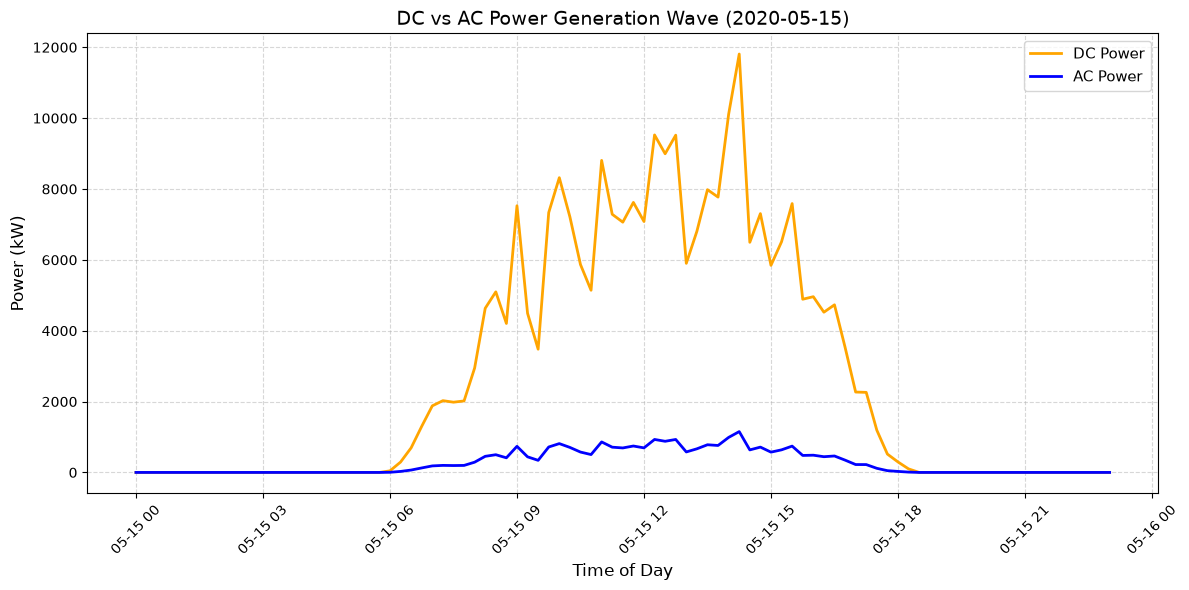

In [7]:
# 1. Specify the target date to analyze (Feel free to change the date for experimentation)
target_date = '2020-05-15'

# 2. Filter the dataset to include only the specified target date
day_df = plant1_gen_df[plant1_gen_df['DATE_TIME'].dt.date == pd.to_datetime(target_date).date()]

# 3. Calculate the average across all inverters since performance varies slightly per device
# (You can also filter by a specific SOURCE_KEY here if you want to inspect a single inverter)
hourly_avg = day_df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].mean().reset_index()

# 4. Plot the time-series comparative line chart
plt.figure(figsize=(12, 6))
# Updated labels to standard English to prevent any UserWarning font errors
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['DC_POWER'], label='DC Power', color='orange', lw=2)
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['AC_POWER'], label='AC Power', color='blue', lw=2)

plt.title(f"DC vs AC Power Generation Wave ({target_date})", fontsize=14)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Power (kW)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

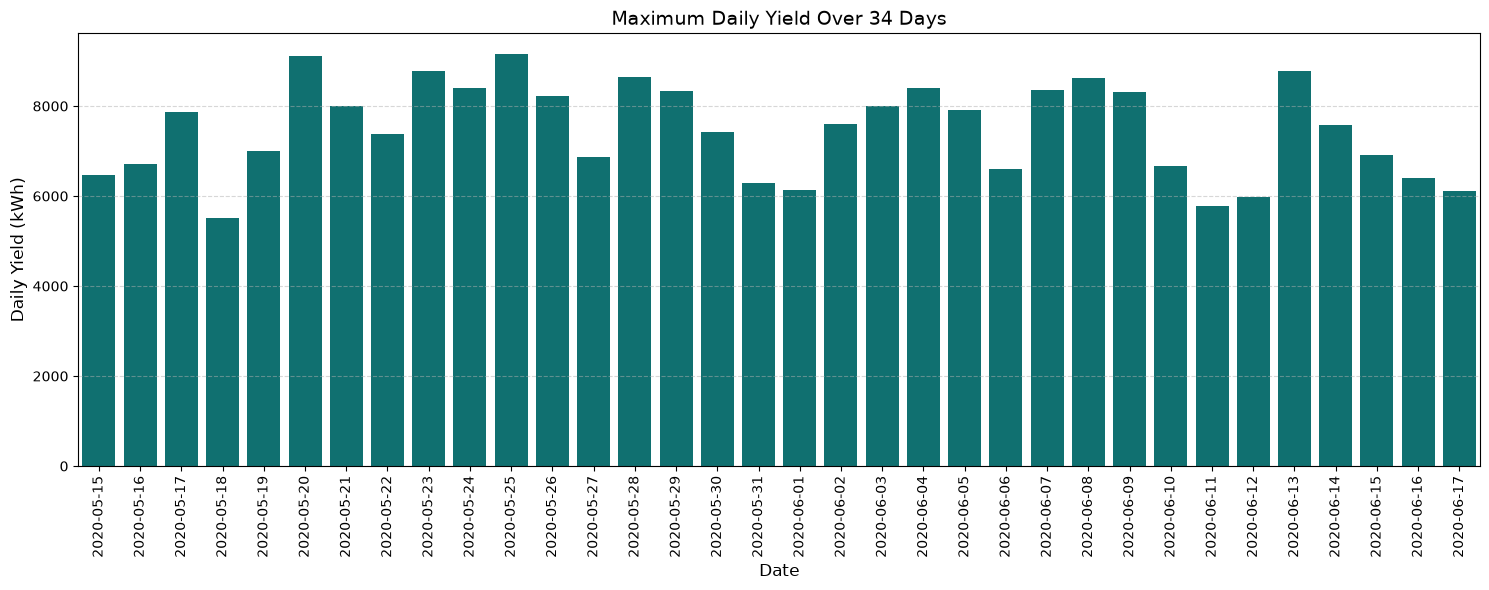

In [8]:
# 1. Create a temporary column extracting only the 'DATE' from DATE_TIME
plant1_gen_df['DATE'] = plant1_gen_df['DATE_TIME'].dt.date

# 2. Calculate the maximum DAILY_YIELD for each date (representing the final cumulative yield of the day)
daily_yield_max = plant1_gen_df.groupby('DATE')['DAILY_YIELD'].max().reset_index()

# 3. Plot the daily maximum yield as a bar chart
plt.figure(figsize=(15, 6))
sns.barplot(data=daily_yield_max, x='DATE', y='DAILY_YIELD', color='teal')

plt.title("Maximum Daily Yield Over 34 Days", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Yield (kWh)", fontsize=12)
plt.xticks(rotation=90) # Rotate x-axis labels by 90 degrees for better readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

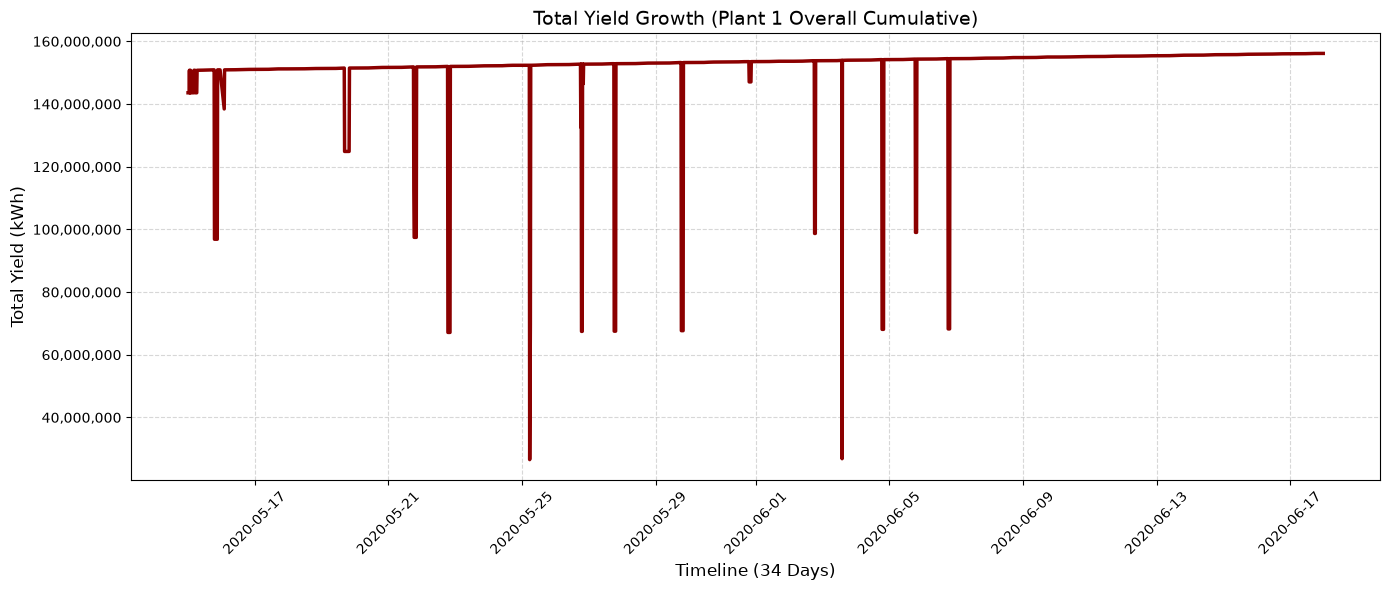

In [9]:
# 1. Calculate the total cumulative yield across all inverters for each timestamp
total_yield_trend = plant1_gen_df.groupby('DATE_TIME')['TOTAL_YIELD'].sum().reset_index()

# 2. Plot the time-series line chart
plt.figure(figsize=(14, 6))
plt.plot(total_yield_trend['DATE_TIME'], total_yield_trend['TOTAL_YIELD'], color='darkred', lw=2.5)

plt.title("Total Yield Growth (Plant 1 Overall Cumulative)", fontsize=14)
plt.xlabel("Timeline (34 Days)", fontsize=12)
plt.ylabel("Total Yield (kWh)", fontsize=12)

# Disable scientific notation (e.g., 1e7) on the y-axis for better readability
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the DATE_TIME column with explicit format
plant1_weather_df['DATE_TIME'] = pd.to_datetime(plant1_weather_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

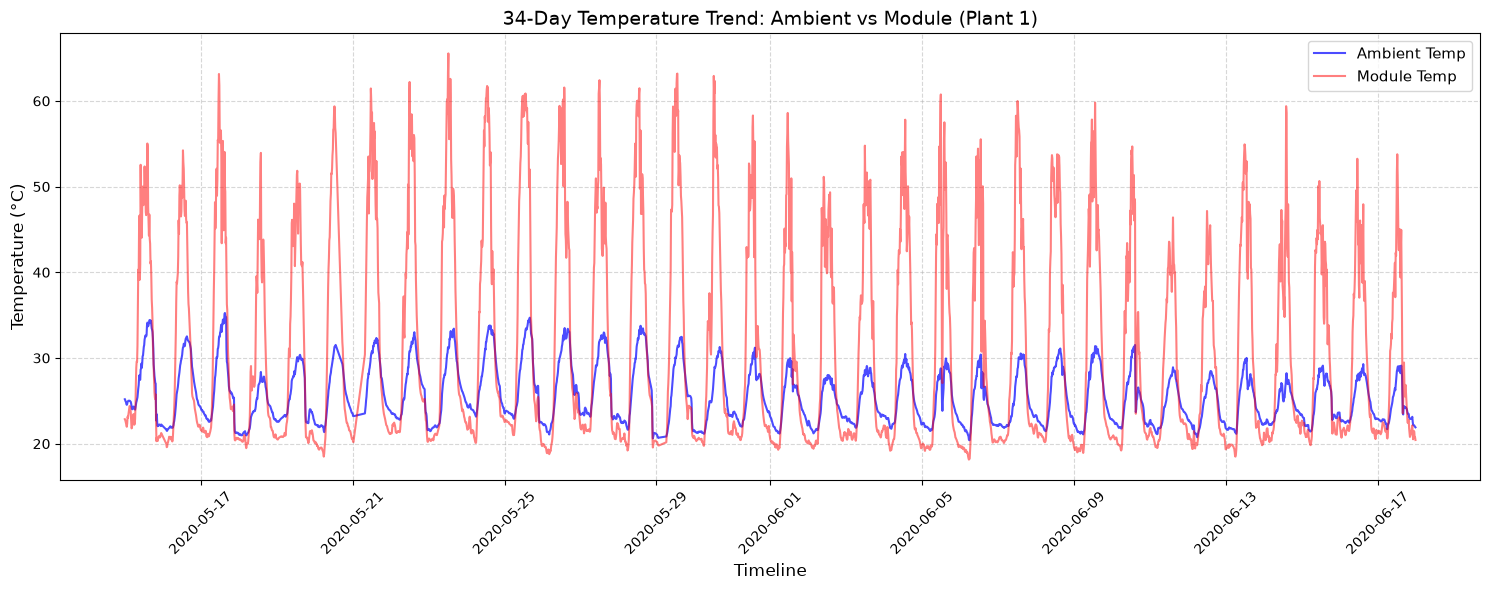

In [11]:
plt.figure(figsize=(15, 6))

# Plot the ambient and module temperatures overlapping each other
# Updated labels to standard English to prevent any UserWarning font errors
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['AMBIENT_TEMPERATURE'], label='Ambient Temp', color='blue', alpha=0.7)
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['MODULE_TEMPERATURE'], label='Module Temp', color='red', alpha=0.5)

plt.title("34-Day Temperature Trend: Ambient vs Module (Plant 1)", fontsize=14)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

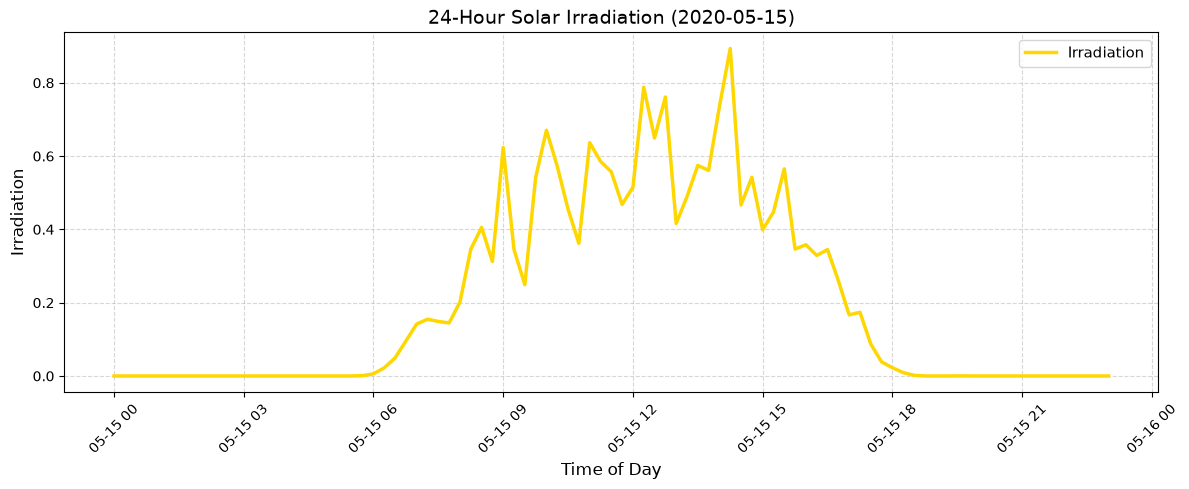

In [12]:
# 1. Specify the target date to analyze (Matching it with the generation data date is a best practice!)
target_date_weather = '2020-05-15'

# 2. Filter the dataset to include only the specified target date
day_weather_df = plant1_weather_df[plant1_weather_df['DATE_TIME'].dt.date == pd.to_datetime(target_date_weather).date()]

# 3. Plot the time-series line chart for solar irradiation
plt.figure(figsize=(12, 5))
# Updated label to standard English to prevent any UserWarning font errors
plt.plot(day_weather_df['DATE_TIME'], day_weather_df['IRRADIATION'], color='gold', lw=2.5, label='Irradiation')

plt.title(f"24-Hour Solar Irradiation ({target_date_weather})", fontsize=14)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Irradiation", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Calculate daily summary statistics (Max, Min, Mean, Median) for both DAILY_YIELD and DC_POWER
# This helps us pinpoint faulty days and system anomalies before diving into visualization
daily_summary = plant1_gen_df.groupby('DATE').agg({
    'DAILY_YIELD': ['max', 'min', 'mean', 'median', 'count'],
    'DC_POWER': ['max', 'min', 'mean', 'median']
}).reset_index()

# Flatten the multi-level columns for cleaner readability
daily_summary.columns = [
    'Date', 
    'Yield_Max', 'Yield_Min', 'Yield_Mean', 'Yield_Median', 'Data_Points',
    'DC_Max', 'DC_Min', 'DC_Mean', 'DC_Median'
]

# Display the entire 34-day summary table to spot anomalies instantly
daily_summary

,Date,Yield_Max,Yield_Min,Yield_Mean,Yield_Median,Data_Points,DC_Max,DC_Min,DC_Mean,DC_Median
0,2020-05-15,6471.000000,0.0,2586.279926,1646.785715,1954,12319.14286,0.0,2879.856266,690.812500
1,2020-05-16,6714.000000,0.0,3464.273323,3866.357143,1934,11986.57143,0.0,3002.139358,1051.875000
2,2020-05-17,7867.000000,0.0,3695.106669,3819.750000,2112,13217.42857,0.0,3200.565600,128.000000
3,2020-05-18,5506.000000,0.0,2429.114465,1601.473215,2112,13382.75000,0.0,2278.668814,275.571429
4,2020-05-19,7007.000000,0.0,2962.975236,1699.785714,1990,11911.50000,0.0,2732.640629,0.000000
5,2020-05-20,9102.000000,0.0,3356.779939,1393.062500,1672,13241.14286,0.0,3215.063260,0.000000
6,2020-05-21,7993.000000,0.0,4844.519541,5919.000000,1368,14038.28571,0.0,4956.921159,4842.257143
7,2020-05-22,7378.000000,0.0,2739.611023,1139.857143,2028,14300.28571,0.0,3166.017999,531.437500
8,2020-05-23,8783.000000,0.0,4325.328418,4603.214286,1958,13848.00000,0.0,3896.944424,1023.883929
9,2020-05-24,8397.000000,0.0,3873.698458,3591.616072,2112,13286.14286,0.0,3390.319078,383.732143


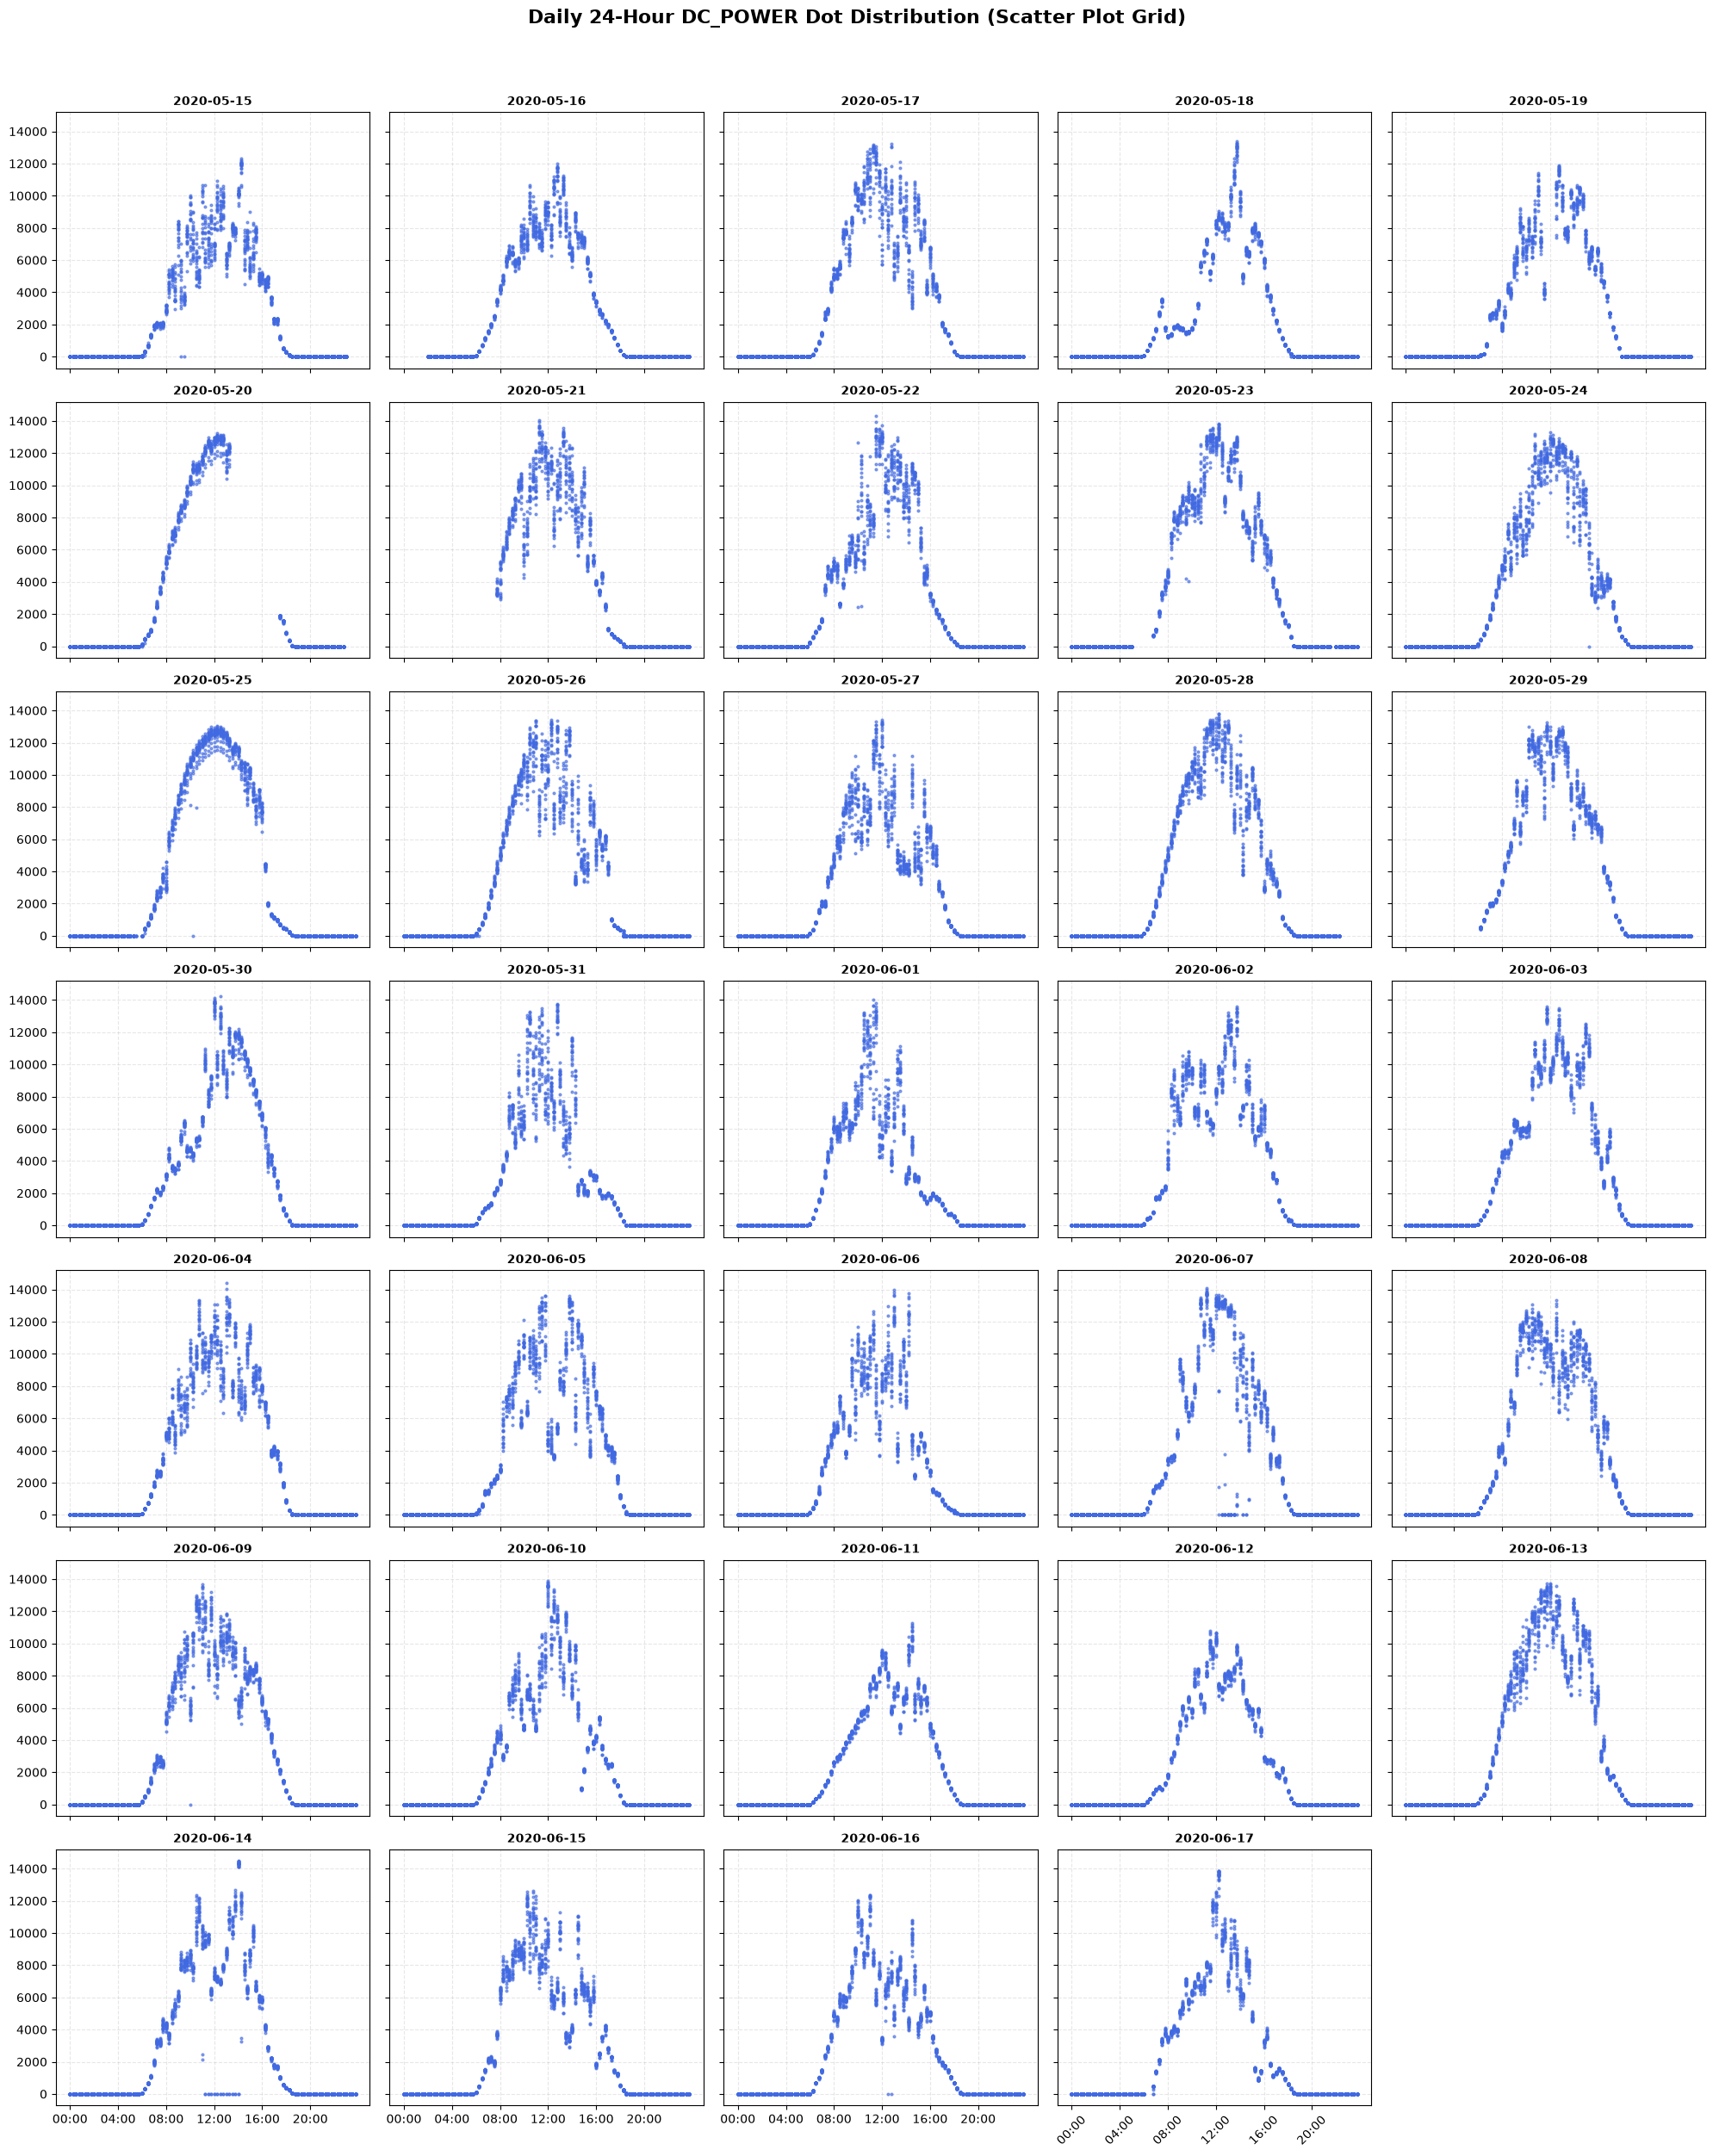

In [14]:
import math
import pandas as pd

# ==============================================================================
# PIPELINE SAFE TIME-EXTRACTION & SCATTER PLOT GRID
# ==============================================================================

# 1. Create your clean staging copies to avoid altering original raw dataframes
p1_gen_clean = plant1_gen_df.copy()

# 2. Safely generate uniform date and time strings needed for conditional grouping
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

# 3. Get a unique sorted list of all 34 dates from the engineered array
unique_dates = sorted(p1_gen_clean['DATE_STR'].unique())
total_plots = len(unique_dates)

cols = 5
rows = math.ceil(total_plots / cols)

# 4. Initialize the subplot grid with shared axes for absolute comparison scaling
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.5), sharex=True, sharey=True)
axes = axes.flatten()

# 5. Loop through each date and plot its 24-hour DC_POWER tracking dots
for i, current_date in enumerate(unique_dates):
    day_df = p1_gen_clean[p1_gen_clean['DATE_STR'] == current_date].sort_values('DATE_TIME')
    
    # Plot as individual dots using marker='.' and removing the connecting line
    axes[i].plot(day_df['TIME_STR'], day_df['DC_POWER'], marker='.', linestyle='None', color='royalblue', alpha=0.6, markersize=4)
    
    axes[i].set_title(current_date, fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.3)

# 6. Remove empty subplot grid containers
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Global layouts
fig.suptitle("Daily 24-Hour DC_POWER Dot Distribution (Scatter Plot Grid)", fontsize=16, fontweight='bold', y=1.02)

ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::16]) # Show label every 4 hours
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

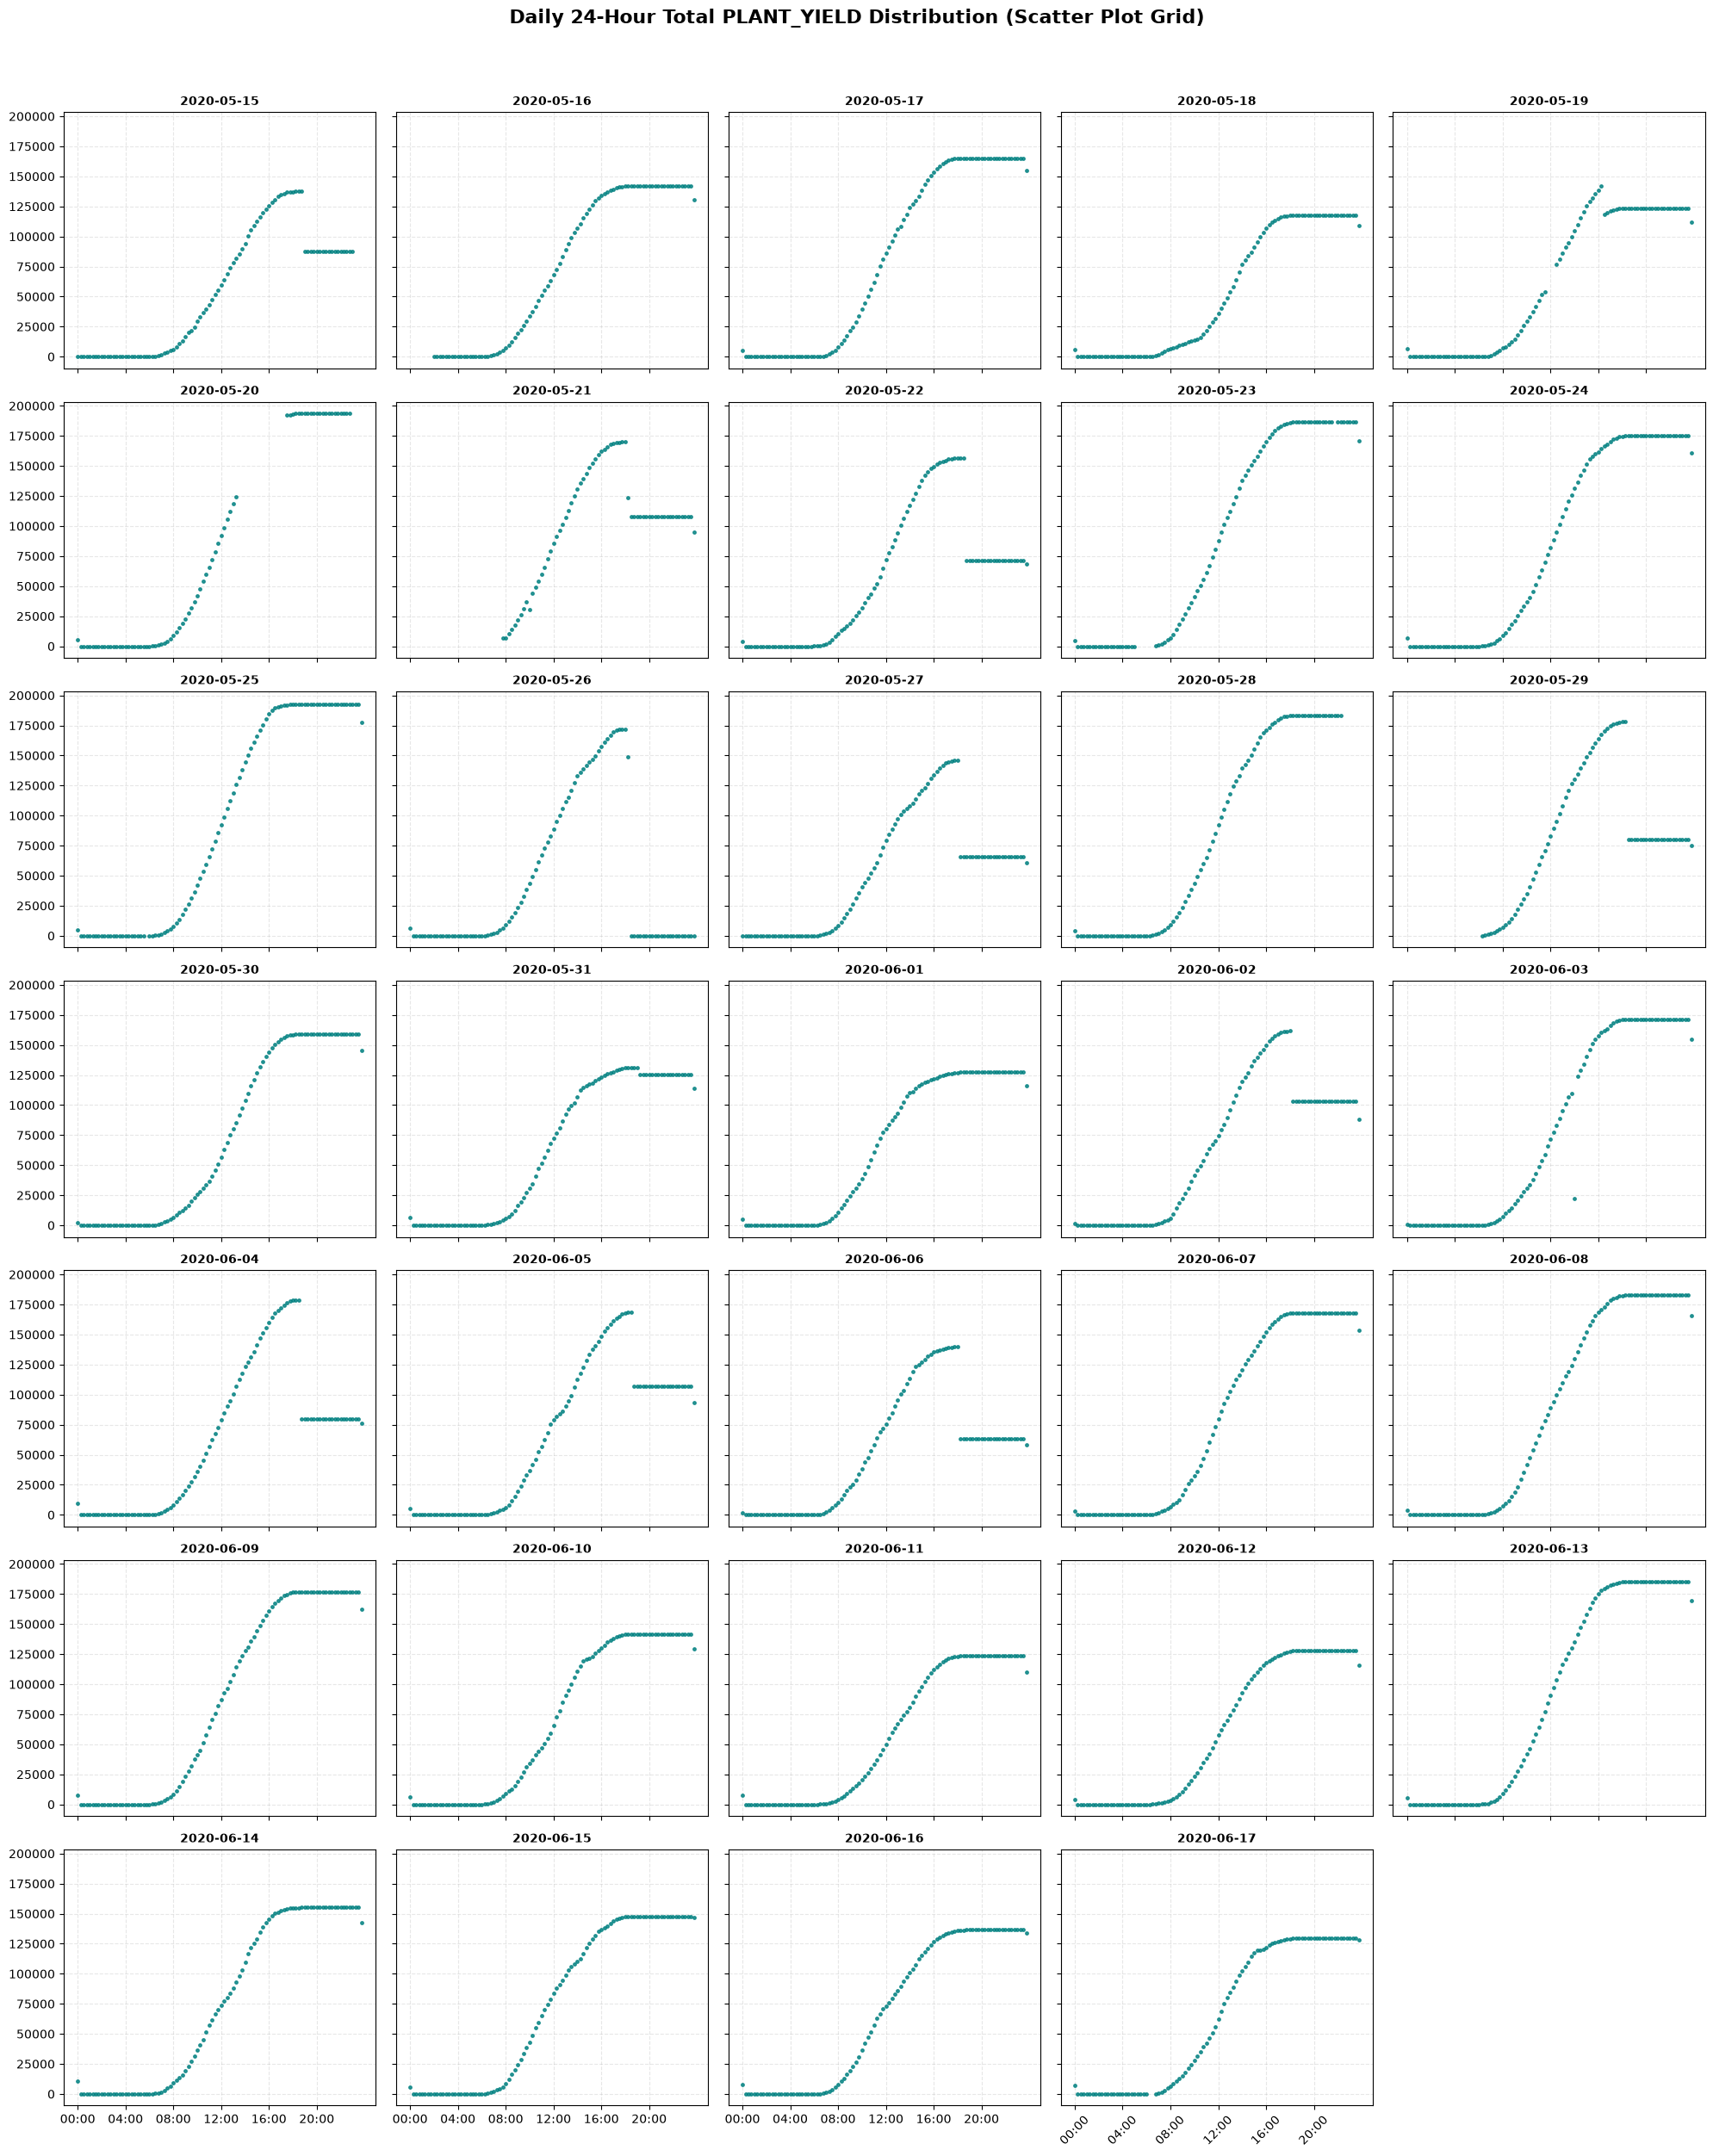

In [15]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PIPELINE SAFE DAILY-YIELD GRID PLOT
# ==============================================================================

# 1. Create a safe staging copy to protect original data and avoid altering the raw dataframe
p1_gen_clean = plant1_gen_df.copy()

# 2. Safely generate uniform date and time strings needed for conditional grouping on the fly
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

# 3. Group by Date and Time to calculate the SUM of DAILY_YIELD across all 22 inverters
# Fixed here: Reference p1_gen_clean which has the freshly generated 'DATE_STR' and 'TIME_STR'
plant_total_yield = p1_gen_clean.groupby(['DATE_STR', 'TIME_STR', 'DATE_TIME'])['DAILY_YIELD'].sum().reset_index()

# 4. Get the unique sorted list of all 34 dates
unique_dates = sorted(plant_total_yield['DATE_STR'].unique())
total_plots = len(unique_dates)

cols = 5
rows = math.ceil(total_plots / cols)

# 5. Initialize the subplot grid with shared axes for flawless visual comparison
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.5), sharex=True, sharey=True)
axes = axes.flatten()

# 6. Loop through each date and plot the plant's total cumulative yield as dots
for i, current_date in enumerate(unique_dates):
    day_df = plant_total_yield[plant_total_yield['DATE_STR'] == current_date].sort_values('DATE_TIME')
    
    # Plotting as scatter dots (marker='.') without any connecting lines
    axes[i].plot(day_df['TIME_STR'], day_df['DAILY_YIELD'], marker='.', linestyle='None', color='teal', alpha=0.8, markersize=5)
    
    axes[i].set_title(current_date, fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.3)

# 7. Remove empty grid tiles
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Global layout styling
fig.suptitle("Daily 24-Hour Total PLANT_YIELD Distribution (Scatter Plot Grid)", fontsize=16, fontweight='bold', y=1.02)

ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::16]) # Show x-label every 4 hours
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# ==============================================================================
# PIPELINE SAFE DAILY DIAGNOSTIC METRICS & QUALITY CHECK
# ==============================================================================

# 1. Create a safe staging copy to protect original data and avoid altering the raw dataframe
p1_gen_clean = plant1_gen_df.copy()

# 2. Safely generate uniform date string needed for grouping on the fly
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')

# 3. Group by Date using the freshly generated 'DATE_STR' column
# This gives us the total cumulative energy generated by the entire plant at any 15-minute mark
cleaning_check = p1_gen_clean.groupby('DATE_STR').agg({
    'DAILY_YIELD': 'max',
    'DC_POWER': 'max',
    'DATE_TIME': 'count' # This counts total Data_Points for the day
}).reset_index()

cleaning_check.columns = ['Date', 'Max_Yield', 'Max_DC', 'Data_Points']

# 4. Automatically flag days that fail our strict quality standards
# Standard 1: Data_Points must be exactly 2112
# Standard 2: Max_Yield should be healthy (e.g., above 1000 kWh to filter out near-zero failure days)
flagged_outages = cleaning_check[cleaning_check['Data_Points'] < 2112]
flagged_low_perf = cleaning_check[(cleaning_check['Max_Yield'] < 4000) & (cleaning_check['Data_Points'] == 2112)]

print("=== [CRITICAL ERROR] Days with Missing Data (Data_Points < 2112) ===")
print(flagged_outages.to_string(index=False))

print("\n=== [WARNING] Days with Extremely Low Performance / Complete Drops ===")
print(flagged_low_perf.to_string(index=False))

=== [CRITICAL ERROR] Days with Missing Data (Data_Points < 2112) ===
      Date   Max_Yield      Max_DC  Data_Points
2020-05-15 6471.000000 12319.14286         1954
2020-05-16 6714.000000 11986.57143         1934
2020-05-19 7007.000000 11911.50000         1990
2020-05-20 9102.000000 13241.14286         1672
2020-05-21 7993.000000 14038.28571         1368
2020-05-22 7378.000000 14300.28571         2028
2020-05-23 8783.000000 13848.00000         1958
2020-05-25 9163.000000 13060.71429         2060
2020-05-26 8222.000000 13434.42857         2072
2020-05-27 6857.000000 13402.87500         2052
2020-05-28 8636.000000 13810.57143         1980
2020-05-29 8343.000000 13236.57143         1490
2020-05-31 6300.000000 13774.14286         2106
2020-06-02 7607.000000 13579.57143         2088
2020-06-03 8010.000000 13579.42857         2094
2020-06-04 8391.714286 14413.42857         2052
2020-06-05 7920.000000 13598.57143         2080
2020-06-06 6603.000000 13958.14286         2052
2020-06-17 6110.000

In [17]:
import pandas as pd

# ==============================================================================
# PIPELINE SAFE NOONTIME CULPRIT HUNTING
# ==============================================================================

# 1. Create a safe staging copy to protect original data and avoid altering the raw dataframe
p1_gen_clean = plant1_gen_df.copy()

# 2. Safely generate uniform date and time strings needed for conditional grouping on the fly
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

# 3. Filter data strictly for peak operational hours (11:00 AM - 03:00 PM) 
# Fixed here: Reference p1_gen_clean which has the freshly generated 'TIME_STR'
peak_df = p1_gen_clean[(p1_gen_clean['TIME_STR'] >= '11:00') & (p1_gen_clean['TIME_STR'] <= '15:00')]

# 4. Group by Date and Inverter ID to find who is outputting exactly 0.0 during peak hours
# We count how many 15-minute intervals each inverter spent at "0" power during noon
culprit_hunting = peak_df.groupby(['DATE_STR', 'SOURCE_KEY']).agg({
    'DC_POWER': lambda x: (x == 0.0).sum() # Count how many times DC_POWER was 0
}).reset_index()

culprit_hunting.columns = ['Date', 'Inverter_ID', 'Zero_Power_Count_At_Noon']

# 5. Filter for the actual culprits that spent more than 4 intervals (1 hour) dead at noon
# This filters out minor cloud shadows and targets real hardware failures
detected_culprits = culprit_hunting[culprit_hunting['Zero_Power_Count_At_Noon'] > 4]

print("=== [FOUND] Identified Faulty Inverters per Specific Date ===")
print(detected_culprits.to_string(index=False))

=== [FOUND] Identified Faulty Inverters per Specific Date ===
      Date     Inverter_ID  Zero_Power_Count_At_Noon
2020-06-07 1BY6WEcLGh8j5v7                         7
2020-06-07 bvBOhCH3iADSZry                         8
2020-06-07 wCURE6d3bPkepu2                         5
2020-06-07 z9Y9gH1T5YWrNuG                         6
2020-06-14 1BY6WEcLGh8j5v7                        12
2020-06-14 bvBOhCH3iADSZry                        12


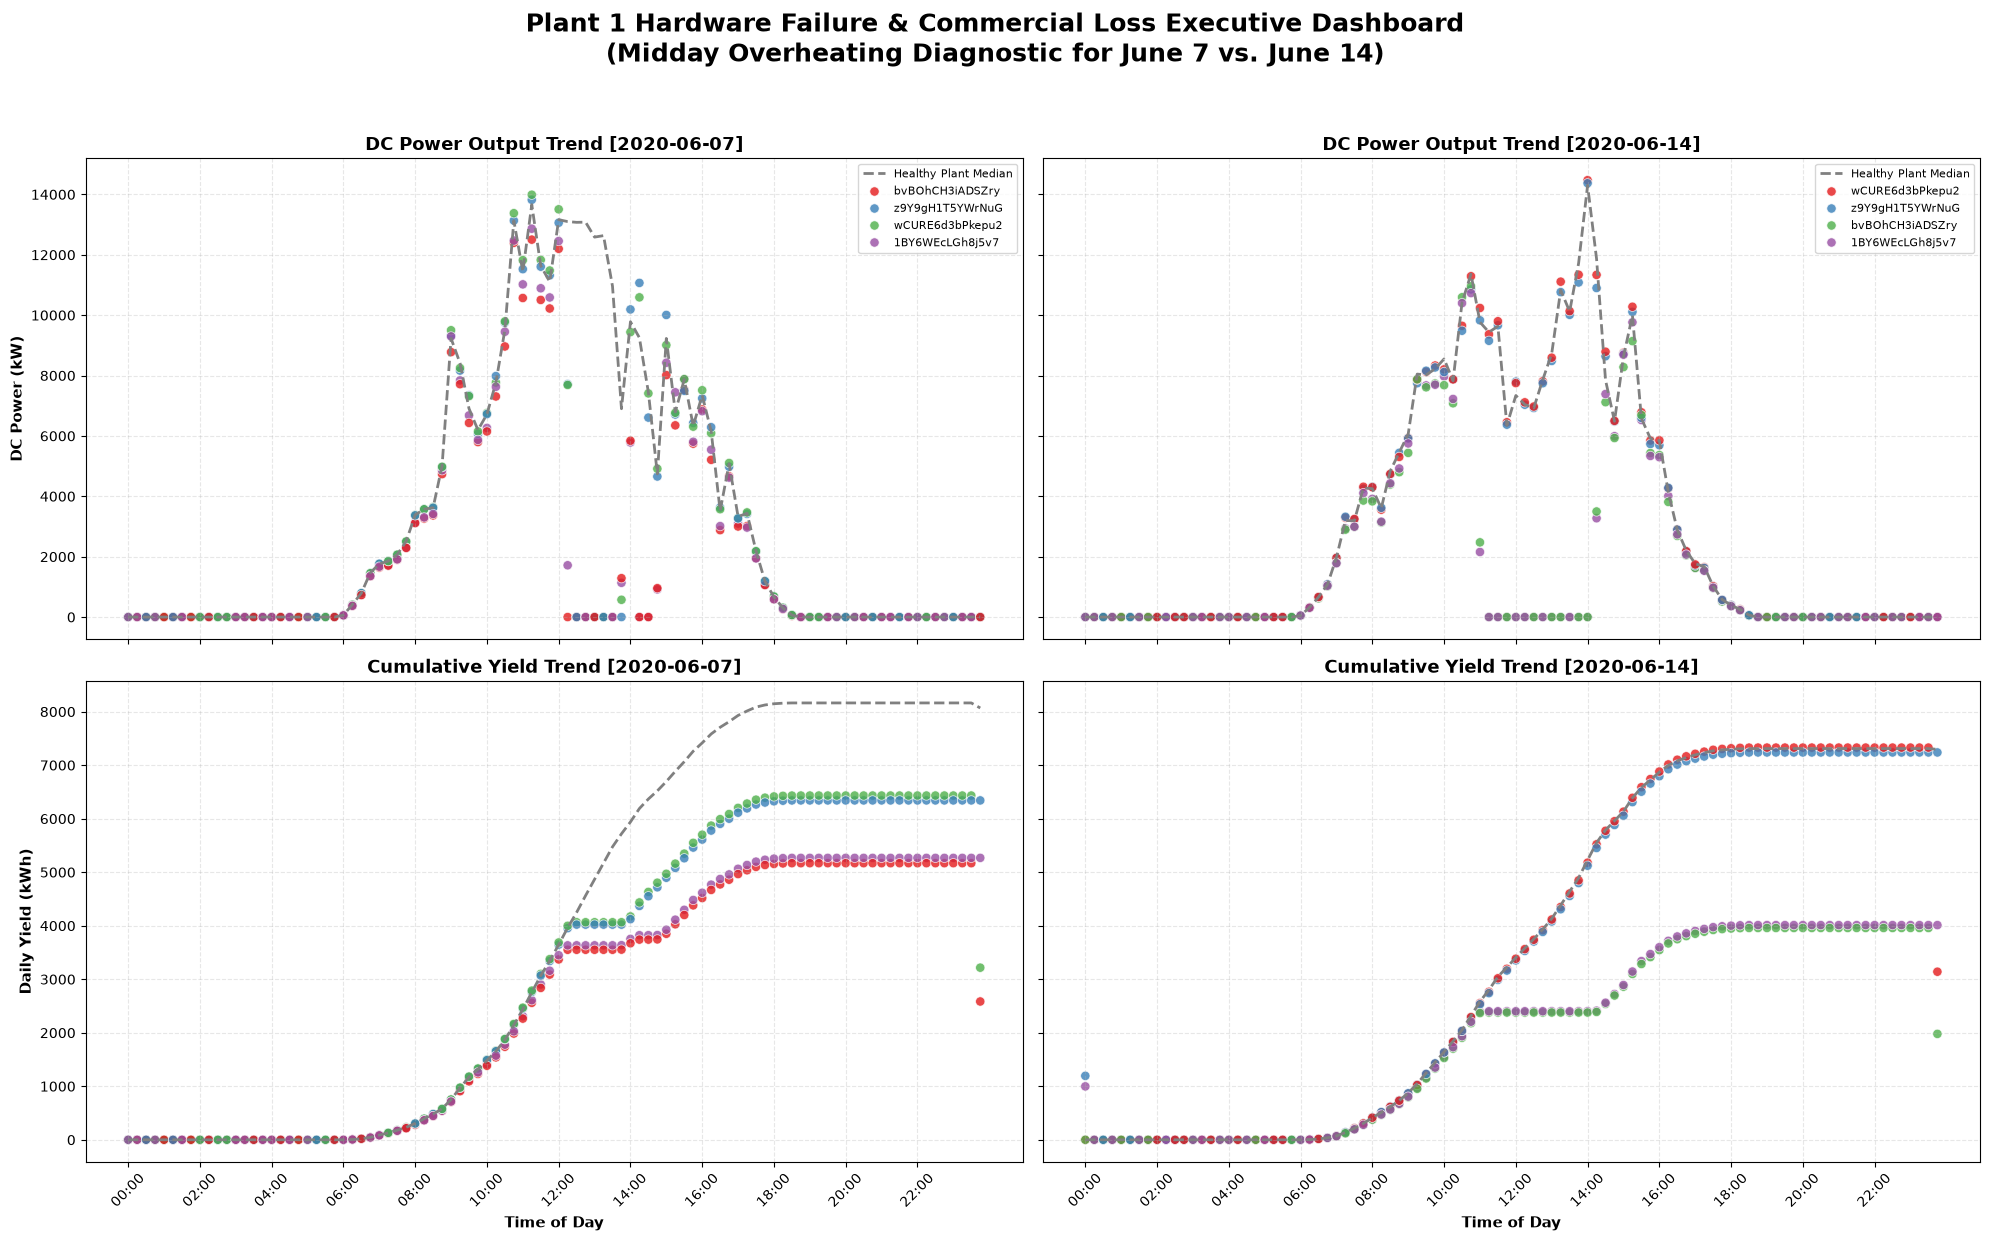

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# PIPELINE SAFE EXECUTIVE HARDWARE DIAGNOSTIC DASHBOARD
# ==============================================================================

# 1. Create a safe staging copy to protect original data and avoid altering the raw dataframe
p1_gen_clean = plant1_gen_df.copy()

# 2. Safely generate uniform date and time strings needed for conditional grouping and plotting
p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

# 3. Prepare the Healthy Plant Benchmarks (Median) for both metrics using the clean staging array
median_dc = p1_gen_clean.groupby('DATE_TIME')['DC_POWER'].median().reset_index().rename(columns={'DC_POWER': 'PLANT_DC_MEDIAN'})
median_yield = p1_gen_clean.groupby('DATE_TIME')['DAILY_YIELD'].median().reset_index().rename(columns={'DAILY_YIELD': 'PLANT_YIELD_MEDIAN'})

# Merge everything back into a master diagnostic dataframe
dash_df = pd.merge(p1_gen_clean, median_dc, on='DATE_TIME', how='left')
dash_df = pd.merge(dash_df, median_yield, on='DATE_TIME', how='left').sort_values('DATE_TIME')

# Define target elements
target_dates = ['2020-06-07', '2020-06-14']
culprit_ids = ['1BY6WEcLGh8j5v7', 'bvBOhCH3iADSZry', 'wCURE6d3bPkepu2', 'z9Y9gH1T5YWrNuG']

# 4. Initialize a large 2x2 dashboard canvas (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex='col', sharey='row')

# ==========================================
# ROW 1: DC_POWER ANALYSIS (THE ROOT CAUSE)
# ==========================================
for idx, current_date in enumerate(target_dates):
    day_df = dash_df[dash_df['DATE_STR'] == current_date]
    culprits_day_df = day_df[day_df['SOURCE_KEY'].isin(culprit_ids)].sort_values('DATE_TIME')
    day_df = day_df.sort_values('DATE_TIME')
    
    # Plot Healthy DC Line
    axes[0, idx].plot(day_df['TIME_STR'], day_df['PLANT_DC_MEDIAN'], color='gray', linestyle='--', lw=2, label='Healthy Plant Median')
    # Plot Culprit DC Dots
    sns.scatterplot(data=culprits_day_df, x='TIME_STR', y='DC_POWER', hue='SOURCE_KEY', palette='Set1', s=45, alpha=0.8, ax=axes[0, idx])
    
    axes[0, idx].set_title(f"DC Power Output Trend [{current_date}]", fontsize=13, fontweight='bold')
    axes[0, idx].grid(True, linestyle='--', alpha=0.3)
    if idx == 0:
        axes[0, idx].set_ylabel("DC Power (kW)", fontsize=11, fontweight='bold')
    axes[0, idx].legend(loc='upper right', fontsize=8)

# ==========================================
# ROW 2: DAILY_YIELD ANALYSIS (THE BUSINESS LOSS)
# ==========================================
for idx, current_date in enumerate(target_dates):
    day_df = dash_df[dash_df['DATE_STR'] == current_date]
    culprits_day_df = day_df[day_df['SOURCE_KEY'].isin(culprit_ids)].sort_values('DATE_TIME')
    day_df = day_df.sort_values('DATE_TIME')
    
    # Plot Healthy Yield Line
    axes[1, idx].plot(day_df['TIME_STR'], day_df['PLANT_YIELD_MEDIAN'], color='gray', linestyle='--', lw=2, label='Healthy Plant Median')
    # Plot Culprit Yield Dots
    sns.scatterplot(data=culprits_day_df, x='TIME_STR', y='DAILY_YIELD', hue='SOURCE_KEY', palette='Set1', s=45, alpha=0.8, ax=axes[1, idx], legend=False)
    
    axes[1, idx].set_title(f"Cumulative Yield Trend [{current_date}]", fontsize=13, fontweight='bold')
    axes[1, idx].set_xlabel("Time of Day", fontsize=11, fontweight='bold')
    axes[1, idx].grid(True, linestyle='--', alpha=0.3)
    if idx == 0:
        axes[1, idx].set_ylabel("Daily Yield (kWh)", fontsize=11, fontweight='bold')
        
    # Clean up the timeline x-axis ticks for the bottom row
    axes[1, idx].set_xticks(axes[1, idx].get_xticks()[::8])
    axes[1, idx].tick_params(axis='x', rotation=45)

# 5. Global Dashboard Styling
fig.suptitle("Plant 1 Hardware Failure & Commercial Loss Executive Dashboard\n(Midday Overheating Diagnostic for June 7 vs. June 14)", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [19]:
# View the overall statistical distribution of the weather data without any filtering
print("=== Plant 1 Weather Data Global Summary (describe) ===")
print(plant1_weather_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].describe())

=== Plant 1 Weather Data Global Summary (describe) ===
       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
count          3182.000000         3182.000000  3182.000000
mean             25.531606           31.091015     0.228313
std               3.354856           12.261222     0.300836
min              20.398505           18.140415     0.000000
25%              22.705182           21.090553     0.000000
50%              24.613814           24.618060     0.024653
75%              27.920532           41.307840     0.449588
max              35.252486           65.545714     1.221652


In [20]:
# Select only columns needed for analysis
weather_check_df = plant1_weather_df[['DATE_TIME']].copy()

# Ensure DATE_TIME is in datetime format and create a date string
weather_check_df['DATE_TIME'] = pd.to_datetime(weather_check_df['DATE_TIME'])
weather_check_df['DATE_STR'] = weather_check_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

# Group by Date and count Data_Points for the day
weather_daily_check = weather_check_df.groupby('DATE_STR').count().reset_index()
weather_daily_check.columns = ['Date', 'Data_Points']

# Flag days with missing weather data (Ideal is 96 points)
weather_outage_list = weather_daily_check[weather_daily_check['Data_Points'] < 96]

print("=== [WEATHER] Days with Missing Data (Data_Points < 96) ===")
if len(weather_outage_list) > 0:
    print(weather_outage_list.to_string(index=False))
else:
    print("Perfect! No missing weather data found in the dataset.")

=== [WEATHER] Days with Missing Data (Data_Points < 96) ===
      Date  Data_Points
2020-05-15           93
2020-05-16           88
2020-05-19           93
2020-05-20           80
2020-05-21           68
2020-05-23           90
2020-05-29           79
2020-06-03           95


In [21]:
import os
import pandas as pd

# ==============================================================================
# CRISP-DM STEP 3: DATA PREPARATION (PLANT 1 SPECIFIC PIPELINE)
# ==============================================================================

# ------------------------------------------------------------------------------
# TASK 0: Initialize Plant 1 Dataframes and Standardize Datetime Datatypes
# ------------------------------------------------------------------------------
p1_gen_clean = plant1_gen_df.copy()
p1_weather_clean = plant1_weather_df.copy()

p1_gen_clean['DATE_TIME'] = pd.to_datetime(p1_gen_clean['DATE_TIME'])
p1_weather_clean['DATE_TIME'] = pd.to_datetime(p1_weather_clean['DATE_TIME'])

p1_gen_clean['DATE_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_gen_clean['TIME_STR'] = p1_gen_clean['DATE_TIME'].dt.strftime('%H:%M')

p1_weather_clean['DATE_STR'] = p1_weather_clean['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_weather_clean['TIME_STR'] = p1_weather_clean['DATE_TIME'].dt.strftime('%H:%M')

print("--- TASK 0: Plant 1 Datetime types successfully initialized ---")

--- TASK 0: Plant 1 Datetime types successfully initialized ---


In [22]:
# ------------------------------------------------------------------------------
# TASK 1: Purge Plant 1 Critical Outage Windows (System Blackouts)
# ------------------------------------------------------------------------------
# Deleting the specific 3-day complete communication blackout found in Plant 1
p1_blackout_dates = ['2020-05-19', '2020-05-20', '2020-05-21']
p1_gen_clean = p1_gen_clean[~p1_gen_clean['DATE_STR'].isin(p1_blackout_dates)]

print(f"--- TASK 1: Purged 3 blackout dates. Remaining rows: {p1_gen_clean.shape[0]} ---")

--- TASK 1: Purged 3 blackout dates. Remaining rows: 63748 ---


In [23]:
# ------------------------------------------------------------------------------
# TASK 2: Execute Cross-Sectional Median Imputation for Plant 1 Faulty Inverters
# ------------------------------------------------------------------------------
# Calculate the healthy baseline specifically for Plant 1 array
p1_timestamp_median = p1_gen_clean.groupby('DATE_TIME')['DC_POWER'].median().reset_index()
p1_timestamp_median.columns = ['DATE_TIME', 'HEALTHY_DC_MEDIAN']

p1_gen_clean = pd.merge(p1_gen_clean, p1_timestamp_median, on='DATE_TIME', how='left')

# Target only the midday drops specific to Plant 1 (11:00 AM - 03:00 PM)
p1_is_hardware_fault = (
    (p1_gen_clean['TIME_STR'] >= '11:00') & 
    (p1_gen_clean['TIME_STR'] <= '15:00') & 
    (p1_gen_clean['DC_POWER'] == 0.0)
)

p1_faulty_count = p1_gen_clean[p1_is_hardware_fault].shape[0]
p1_gen_clean.loc[p1_is_hardware_fault, 'DC_POWER'] = p1_gen_clean.loc[p1_is_hardware_fault, 'HEALTHY_DC_MEDIAN']

print(f"--- TASK 2: Detected and repaired {p1_faulty_count} midday inverter faults for Plant 1 ---")

--- TASK 2: Detected and repaired 58 midday inverter faults for Plant 1 ---


In [24]:
# ------------------------------------------------------------------------------
# TASK 3: Relational Feature Merge & Climate Metric Interpolation
# ------------------------------------------------------------------------------
p1_weather_features = p1_weather_clean[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]

# Left join to preserve all sanitized Plant 1 generation data rows
p1_master_df = pd.merge(p1_gen_clean, p1_weather_features, on='DATE_TIME', how='left').sort_values('DATE_TIME')

# Smooth over the minor weather sensor drops using linear interpolation
weather_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
p1_master_df[weather_cols] = p1_master_df[weather_cols].interpolate(method='linear', limit=2)

print("--- TASK 3: Relational merge and weather interpolation completed for Plant 1 ---")

--- TASK 3: Relational merge and weather interpolation completed for Plant 1 ---


In [25]:
# ------------------------------------------------------------------------------
# TASK 4: Export Clean Engineered Features into Structured Storage Directory
# ------------------------------------------------------------------------------
processed_directory = '../data/processed'
os.makedirs(processed_directory, exist_ok=True)

final_output_path = os.path.join(processed_directory, 'plant1_master_features.csv')
p1_master_df.to_csv(final_output_path, index=False)

In [26]:
# ------------------------------------------------------------------------------
# FINAL AUDIT SIGN-OFF
# ------------------------------------------------------------------------------
print("\n==============================================================================")
print(" CRISP-DM STEP 3 STATUS: PLANT 1 DATA SAFELY SIGNED OFF")
print("==============================================================================")
print(f"Saved Destination Path : {final_output_path}")
print(f"Final Data Matrix Shape: {p1_master_df.shape[0]} rows, {p1_master_df.shape[1]} columns")
print(f"Remaining Missing Values inside Dataset:\n{p1_master_df[weather_cols].isnull().sum()}")
print("==============================================================================")


 CRISP-DM STEP 3 STATUS: PLANT 1 DATA SAFELY SIGNED OFF
Saved Destination Path : ../data/processed/plant1_master_features.csv
Final Data Matrix Shape: 63748 rows, 14 columns
Remaining Missing Values inside Dataset:
AMBIENT_TEMPERATURE    2
MODULE_TEMPERATURE     2
IRRADIATION            2
dtype: int64


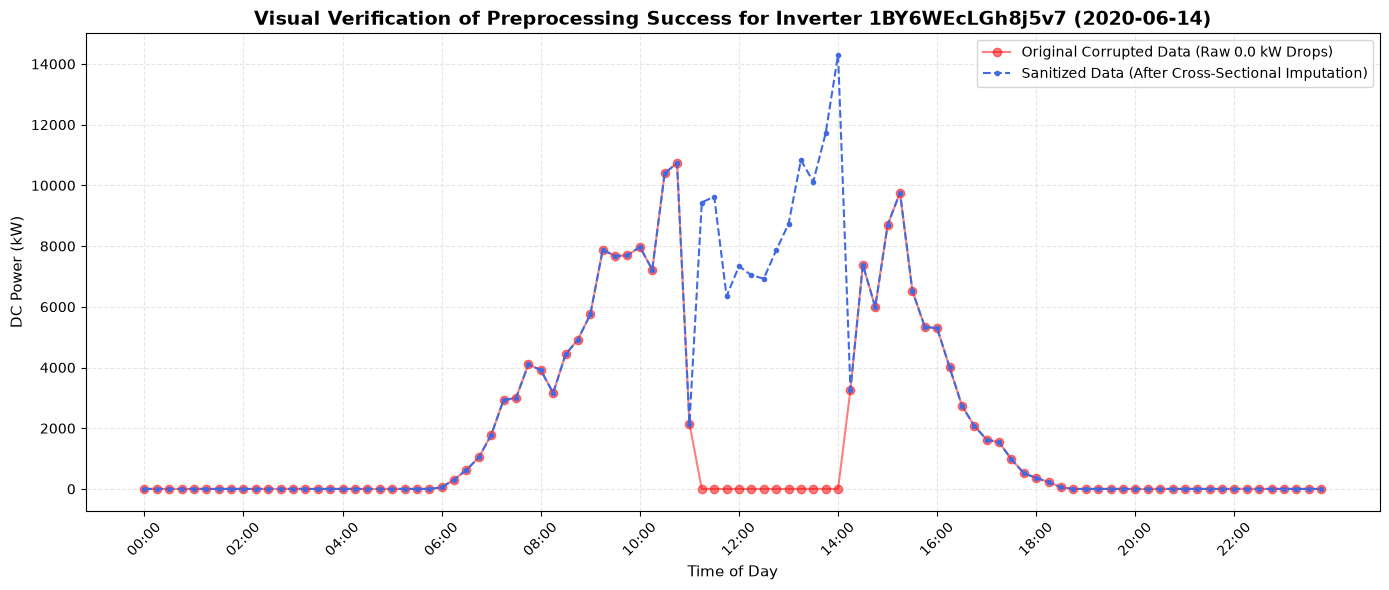

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PIPELINE SAFE VISUAL VERIFICATION (BEFORE VS AFTER PREPROCESSING)
# ==============================================================================

test_date = '2020-06-14'
test_culprit = '1BY6WEcLGh8j5v7'

# 1. Create a safe temporary copy of the raw dataframe and generate strings on the fly
# This replicates exactly how the data looked BEFORE any smart median imputation
raw_staging = plant1_gen_df.copy()
raw_staging['DATE_TIME'] = pd.to_datetime(raw_staging['DATE_TIME'])
raw_staging['DATE_STR'] = raw_staging['DATE_TIME'].dt.strftime('%Y-%m-%d')
raw_staging['TIME_STR'] = raw_staging['DATE_TIME'].dt.strftime('%H:%M')

# 2. Extract the raw corrupted series and your newly sanitized master feature series
raw_day = raw_staging[(raw_staging['DATE_STR'] == test_date) & (raw_staging['SOURCE_KEY'] == test_culprit)].sort_values('DATE_TIME')
clean_day = p1_master_df[(p1_master_df['DATE_STR'] == test_date) & (p1_master_df['SOURCE_KEY'] == test_culprit)].sort_values('DATE_TIME')

# 3. Plot the visual comparison dashboard
plt.figure(figsize=(14, 6))

# Plot the raw data in red (representing the original hardware drop)
plt.plot(raw_day['TIME_STR'], raw_day['DC_POWER'], color='red', marker='o', alpha=0.5, label='Original Corrupted Data (Raw 0.0 kW Drops)')

# Plot your newly cleaned data in blue (representing your smart median imputation)
plt.plot(clean_day['TIME_STR'], clean_day['DC_POWER'], color='royalblue', marker='.', linestyle='--', label='Sanitized Data (After Cross-Sectional Imputation)')

plt.title(f"Visual Verification of Preprocessing Success for Inverter {test_culprit} ({test_date})", fontsize=14, fontweight='bold')
plt.xlabel("Time of Day", fontsize=11)
plt.ylabel("DC Power (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::8])
plt.xticks(rotation=45)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================================================
# BLOCK 1: CHRONOLOGICAL VALIDATION & SCORE METRICS SIGN-OFF
# ==============================================================================

# 1. Synchronize datetime data types and string indexing variables
p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
p1_master_df['DATE_STR'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')
p1_master_df['TIME_STR'] = p1_master_df['DATE_TIME'].dt.strftime('%H:%M')

X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
y_master = p1_master_df['DC_POWER']
dates = p1_master_df['DATE_STR']

# 2. Enforce strict chronological partitioning to eliminate data leakage
# Train interval: Base Start (05/15) ~ 06/11 | Evaluation interval: Unseen Future (06/12 ~ 06/17)
train_mask = dates <= '2020-06-11'
test_mask  = (dates >= '2020-06-12') & (dates <= '2020-06-17')

X_train, y_train = X_master[train_mask], y_master[train_mask]
X_test, y_test   = X_master[test_mask], y_master[test_mask]

print("==============================================================================")
print(" CHRONOLOGICAL DATA PARTITION REPORT")
print("==============================================================================")
print(f"Training Knowledge Base (05/15 ~ 06/11) : {X_train.shape[0]} rows")
print(f"Evaluation Test Window  (06/12 ~ 06/17) : {X_test.shape[0]} rows\n")

# 3. Fit LightGBM regressor on the historical training baseline
verify_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
verify_model.fit(X_train, y_train)

# 4. Execute prospective future forecasting over the blind test window
y_pred = verify_model.predict(X_test)

# 5. Evaluate model performance metrics using global evaluation standards
rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred))
r2_eval = r2_score(y_test, y_pred)

print("==============================================================================")
print(" TRUE TIME-SERIES PERFORMANCE METRICS (6-DAY BLIND TEST)")
print("==============================================================================")
print(f"True Future RMSE     : {rmse_eval:.4f} kW")
print(f"True Future R2 Score : {r2_eval:.4f} ({r2_eval*100:.2f}% Match)")
print("==============================================================================")

 CHRONOLOGICAL DATA PARTITION REPORT
Training Knowledge Base (05/15 ~ 06/11) : 51120 rows
Evaluation Test Window  (06/12 ~ 06/17) : 12628 rows

 TRUE TIME-SERIES PERFORMANCE METRICS (6-DAY BLIND TEST)
True Future RMSE     : 388.5018 kW
True Future R2 Score : 0.9894 (98.94% Match)


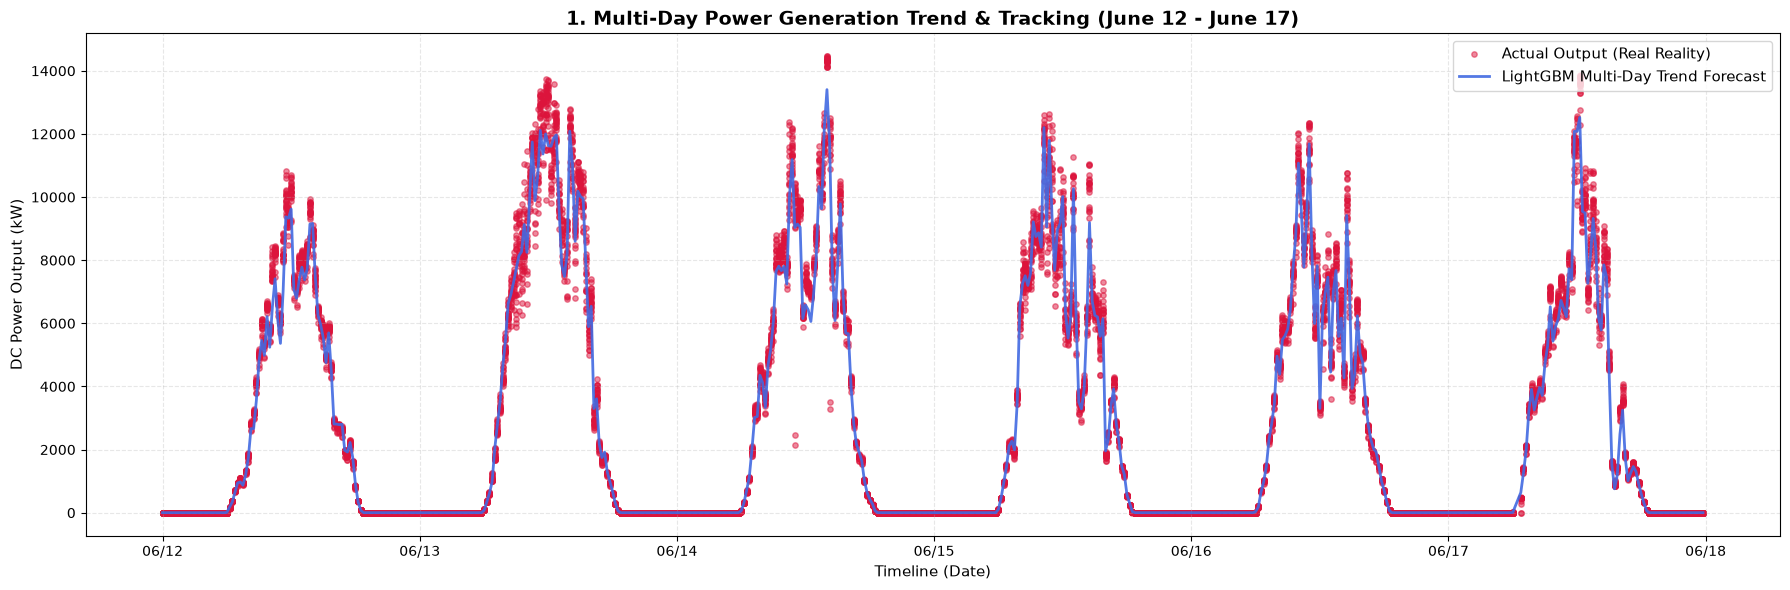

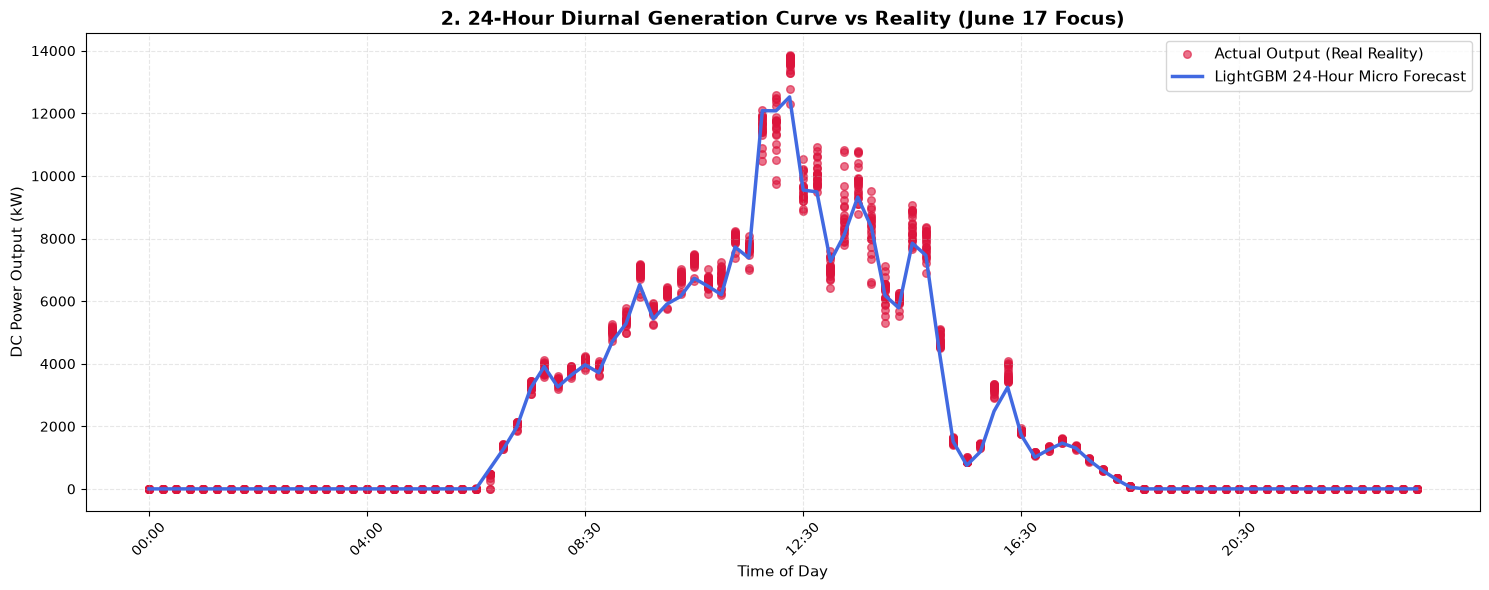

In [29]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# BLOCK 2: PROFESSIONAL VISUALIZATION (TREND & DIURNAL CYCLES)
# ==============================================================================

# [SAFEGUARD] If the notebook memory cache was flushed via a kernel restart, 
# dynamically reconstruct the chronological masks, fit the model, and generate predictions.
if 'y_pred' not in locals() or 'test_mask' not in locals():
    print("※ Notebook memory cache empty. Synchronizing upstream pipeline elements...")
    
    # Enforce precise datetime formatting and string components
    p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
    p1_master_df['DATE_STR'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')
    p1_master_df['TIME_STR'] = p1_master_df['DATE_TIME'].dt.strftime('%H:%M')

    X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    y_master = p1_master_df['DC_POWER']
    dates = p1_master_df['DATE_STR']

    # Separate into strict historical training and unseen test evaluation intervals
    train_mask = dates <= '2020-06-11'
    test_mask  = (dates >= '2020-06-12') & (dates <= '2020-06-17')

    X_train, y_train = X_master[train_mask], y_master[train_mask]
    X_test, y_test   = X_master[test_mask], y_master[test_mask]

    # Quick fit to restore the prediction matrix state variables
    fallback_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    fallback_model.fit(X_train, y_train)
    y_pred = fallback_model.predict(X_test)
    print("--- Upstream data layers verified. Missing state vectors restored. ---\n")

# Create a clean temporary dataframe for the target evaluation window (June 12 - June 17)
eval_df = p1_master_df[test_mask].copy().sort_values('DATE_TIME')
eval_df['PRED_DC_POWER'] = y_pred

# ------------------------------------------------------------------------------
# CHART 1: [Multi-Day Trend] Macro tracking across consecutive dates
# ------------------------------------------------------------------------------
plt.figure(figsize=(18, 6))

# Plot the real historical truth as crimson scatter points
plt.scatter(eval_df['DATE_TIME'], eval_df['DC_POWER'], 
            color='crimson', alpha=0.5, s=15, label='Actual Output (Real Reality)')

# Plot the model forecasts as a continuous, smooth royalblue tracking line
plt.plot(eval_df['DATE_TIME'], eval_df['PRED_DC_POWER'], 
         color='royalblue', lw=2, alpha=0.9, label='LightGBM Multi-Day Trend Forecast')

# Format the X-axis tick distribution cleanly into day intervals
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())

plt.title("1. Multi-Day Power Generation Trend & Tracking (June 12 - June 17)", fontsize=14, fontweight='bold')
plt.xlabel("Timeline (Date)", fontsize=11)
plt.ylabel("DC Power Output (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# CHART 2: [24-Hour Diurnal Profile] Micro physical curve verification on a single day
# ------------------------------------------------------------------------------
# Pinpoint the final operational day (June 17) for localized macro inspection
final_day_df = eval_df[eval_df['DATE_STR'] == '2020-06-17'].sort_values('DATE_TIME')

plt.figure(figsize=(15, 6))

# Overlay real metrics dots with the model's predictive tracking horizon line
plt.scatter(final_day_df['TIME_STR'], final_day_df['DC_POWER'], 
            color='crimson', alpha=0.6, s=30, label='Actual Output (Real Reality)')
plt.plot(final_day_df['TIME_STR'], final_day_df['PRED_DC_POWER'], 
         color='royalblue', lw=2.5, label='LightGBM 24-Hour Micro Forecast')

# Reduce horizontal density by displaying a timestamp tick index every 4 hours (15 mins * 16 steps)
ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::16])
plt.xticks(rotation=45)

plt.title("2. 24-Hour Diurnal Generation Curve vs Reality (June 17 Focus)", fontsize=14, fontweight='bold')
plt.xlabel("Time of Day", fontsize=11)
plt.ylabel("DC Power Output (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

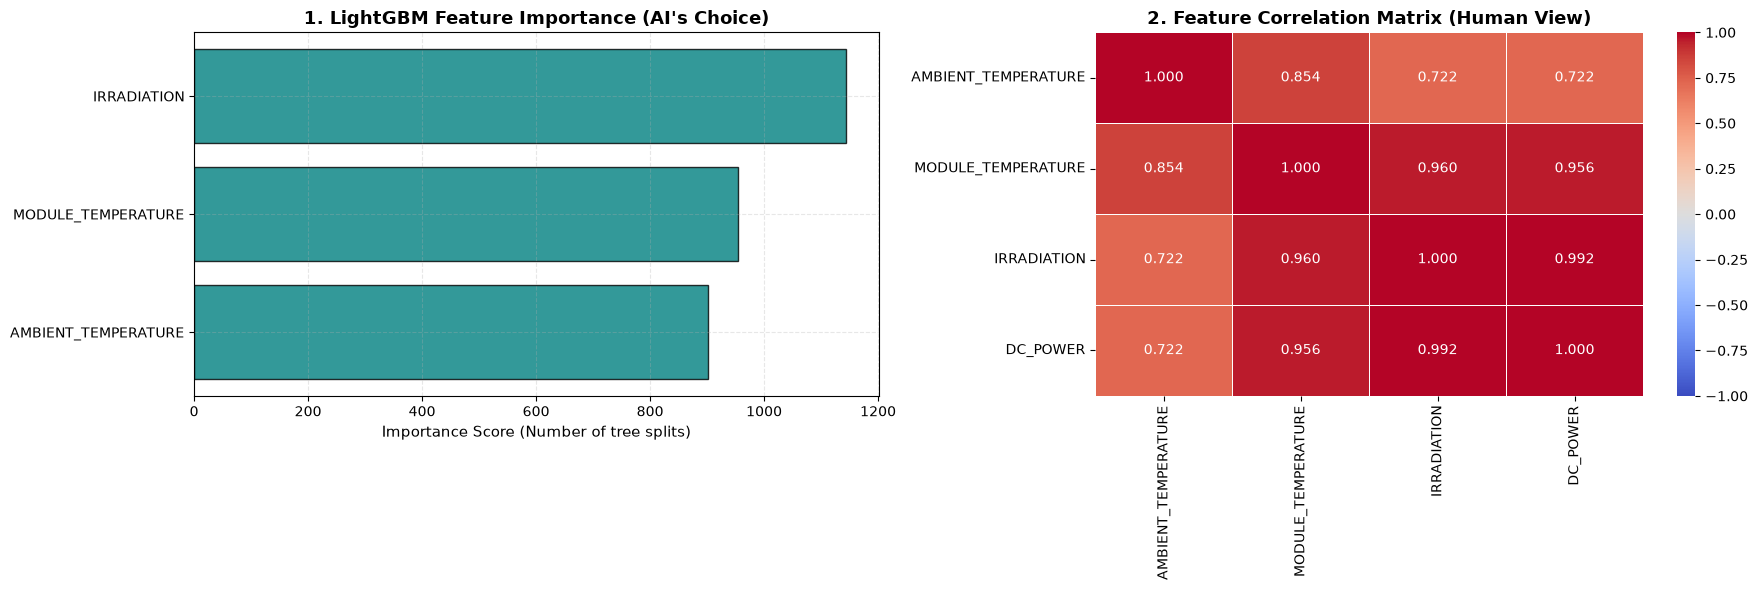

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import lightgbm as lgb

# ==============================================================================
# BLOCK 1: MODEL CAUSALITY & FEATURE CORRELATION ANALYSIS (1 & 2)
# ==============================================================================

# [SAFEGUARD] If the notebook memory cache was flushed via a kernel restart,
# dynamically reconstruct the dataset split and re-fit the baseline model.
if 'verify_model' not in locals() or 'X_train' not in locals():
    print("※ Notebook memory cache empty. Synchronizing upstream training elements...")
    
    # Enforce date-time formats and extract clean string representations
    p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
    p1_master_df['DATE_STR'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

    X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    y_master = p1_master_df['DC_POWER']
    dates = p1_master_df['DATE_STR']

    # Separate into strict historical training and unseen test validation intervals
    train_mask = dates <= '2020-06-11'
    X_train, y_train = X_master[train_mask], y_master[train_mask]

    # Re-fit parameters to initialize model attributes for the feature check
    verify_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    verify_model.fit(X_train, y_train)
    print("--- Upstream data layers verified. Missing model vectors restored. ---\n")

# Initialize a 1x2 dual-plot visualization grid canvas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ------------------------------------------------------------------------------
# CHART 1: LightGBM Feature Importance (AI's Operational Choice)
# ------------------------------------------------------------------------------
# Extract native node-splitting metrics from the verified LightGBM estimator
importance = verify_model.feature_importances_
feature_names = X_train.columns

# Structure feature records into a sorted visualization dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=True)

# Render a horizontal bar plot showing relative feature contributions
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title("1. LightGBM Feature Importance (AI's Choice)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Importance Score (Number of tree splits)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)


# ------------------------------------------------------------------------------
# CHART 2: Correlation Matrix Heatmap (Surface-Level Human Perspective)
# ------------------------------------------------------------------------------
# Calculate linear Pearson correlation coefficients across target numeric vectors
analysis_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER']
correlation_matrix = p1_master_df[analysis_cols].corr()

# Draw a stylized thematic heatmap matrix with explicit value annotations
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    linewidths=0.5, 
    vmin=-1, vmax=1,
    ax=axes[1]
)
axes[1].set_title("2. Feature Correlation Matrix (Human View)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

 FINANCIAL & OPERATIONAL DAILY YIELD REPORT (JUNE 12 - JUNE 17)
      Date Actual_Daily_Yield(kWh) Predicted_Daily_Yield(kWh) Error_Delta(kWh)
2020-06-12            1,201,141.40               1,144,901.72       -56,239.68
2020-06-13            1,746,568.54               1,715,426.32       -31,142.22
2020-06-14            1,511,346.21               1,451,036.03       -60,310.18
2020-06-15            1,392,773.26               1,387,341.56        -5,431.70
2020-06-16            1,284,979.15               1,261,088.32       -23,890.83
2020-06-17            1,223,089.36               1,176,107.98       -46,981.38



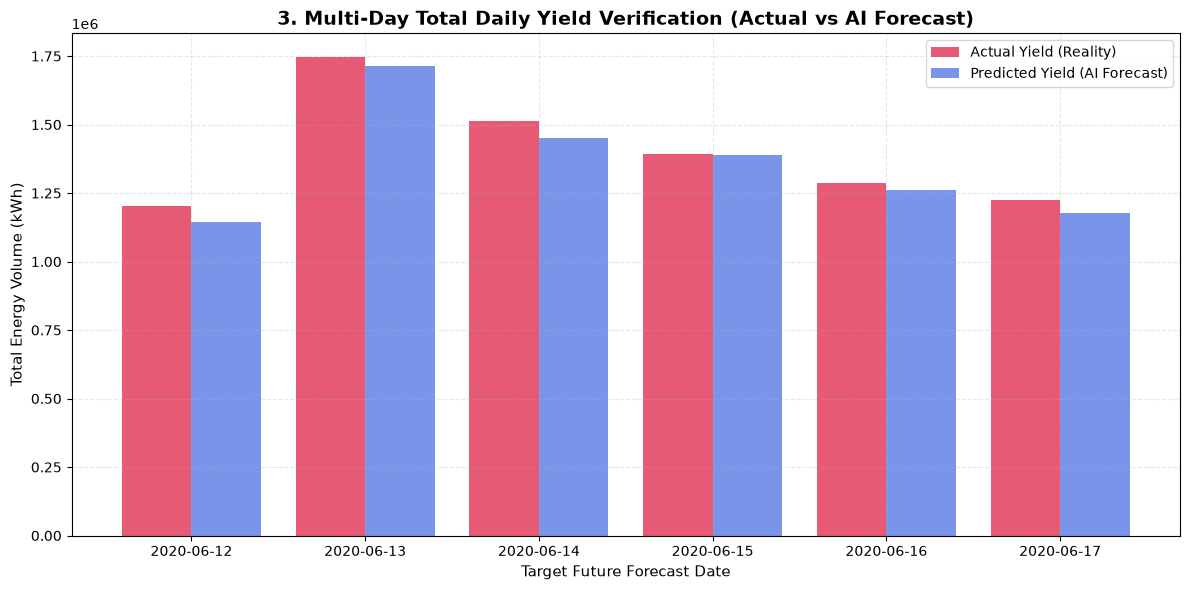

In [31]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

# ==============================================================================
# BLOCK 2: AC CONVERSION & DAILY YIELD INTEGRATION (4)
# ==============================================================================

# [SAFEGUARD] If the notebook memory cache was flushed via a kernel restart, 
# dynamically reconstruct chronological masks, re-fit the model, and generate predictions.
if 'y_pred' not in locals() or 'test_mask' not in locals():
    print("※ Notebook memory cache empty. Synchronizing upstream pipeline elements...")
    
    # Enforce precise datetime formatting and string components
    p1_master_df['DATE_TIME'] = pd.to_datetime(p1_master_df['DATE_TIME'])
    p1_master_df['DATE_STR'] = p1_master_df['DATE_TIME'].dt.strftime('%Y-%m-%d')

    X_master = p1_master_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    y_master = p1_master_df['DC_POWER']
    dates = p1_master_df['DATE_STR']

    # Separate into strict historical training and unseen test evaluation intervals
    train_mask = dates <= '2020-06-11'
    test_mask  = (dates >= '2020-06-12') & (dates <= '2020-06-17')

    X_train, y_train = X_master[train_mask], y_master[train_mask]
    X_test, y_test   = X_master[test_mask], y_master[test_mask]

    # Quick fit to restore prediction state variables
    fallback_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    fallback_model.fit(X_train, y_train)
    y_pred = fallback_model.predict(X_test)
    print("--- Upstream data layers verified. Missing state vectors restored. ---\n")

# 1. Merge AI predictions onto the target test evaluation period dataframe
eval_df = p1_master_df[test_mask].copy().sort_values('DATE_TIME')
eval_df['PRED_DC_POWER'] = y_pred

# 2. [AC POWER CONVERSION] Simulate AC power by applying a standard inverter efficiency factor (92%)
INVERTER_EFFICIENCY = 0.92
eval_df['ACTUAL_AC_POWER_SIM'] = eval_df['DC_POWER'] * INVERTER_EFFICIENCY
eval_df['PRED_AC_POWER_SIM']   = eval_df['PRED_DC_POWER'] * INVERTER_EFFICIENCY

# 3. [DAILY YIELD INTEGRATION] Aggregate 15-minute intervals into cumulative daily metrics
# Integration rule: 15 minutes equals 0.25 hours (kW * 0.25 hours = kWh volume)
eval_df['ACTUAL_KWH'] = eval_df['ACTUAL_AC_POWER_SIM'] * 0.25
eval_df['PRED_KWH']   = eval_df['PRED_AC_POWER_SIM'] * 0.25

# Group by chronological date strings to calculate total aggregated energy (Daily Yield in kWh)
daily_yield_report = eval_df.groupby('DATE_STR')[['ACTUAL_KWH', 'PRED_KWH']].sum().reset_index()

# Rename dataframe columns for clean reporting output
daily_yield_report.columns = ['Date', 'Actual_Daily_Yield(kWh)', 'Predicted_Daily_Yield(kWh)']
daily_yield_report['Error_Delta(kWh)'] = daily_yield_report['Predicted_Daily_Yield(kWh)'] - daily_yield_report['Actual_Daily_Yield(kWh)']

# Print structured operational and financial report to terminal log
print("==============================================================================")
print(" FINANCIAL & OPERATIONAL DAILY YIELD REPORT (JUNE 12 - JUNE 17)")
print("==============================================================================")
print(daily_yield_report.to_string(index=False, formatters={
    'Actual_Daily_Yield(kWh)': '{:,.2f}'.format,
    'Predicted_Daily_Yield(kWh)': '{:,.2f}'.format,
    'Error_Delta(kWh)': '{:+,.2f}'.format
}))
print("==============================================================================\n")


# 4. Render comparative clustered bar chart for Actual vs Predicted Daily Yield
plt.figure(figsize=(12, 6))
x_axis = np.arange(len(daily_yield_report['Date']))

# Map reality metrics as crimson bars and AI prospective forecasts as royalblue bars side-by-side
plt.bar(x_axis - 0.2, daily_yield_report['Actual_Daily_Yield(kWh)'], width=0.4, color='crimson', alpha=0.7, label='Actual Yield (Reality)')
plt.bar(x_axis + 0.2, daily_yield_report['Predicted_Daily_Yield(kWh)'], width=0.4, color='royalblue', alpha=0.7, label='Predicted Yield (AI Forecast)')

plt.xticks(x_axis, daily_yield_report['Date'])
plt.title("3. Multi-Day Total Daily Yield Verification (Actual vs AI Forecast)", fontsize=14, fontweight='bold')
plt.xlabel("Target Future Forecast Date", fontsize=11)
plt.ylabel("Total Energy Volume (kWh)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()